# Model interpretation and reporting

This notebook turns trained model artifacts into more interpretable project outputs. It focuses on feature importance, prediction behavior, and a few error views that are useful for explaining model performance to a non-technical reader.


In [1]:
from pathlib import Path
import warnings

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from sklearn.inspection import PartialDependenceDisplay, permutation_importance
from sklearn.metrics import mean_absolute_error, r2_score, root_mean_squared_error


### Load the cleaned dataset and identify saved models

The notebook reads the modeling-ready parquet file and then checks the local `reports/models` folder for trained pipelines. To keep the workflow practical, it flags very large model files before loading them.


In [2]:
cwd = Path().resolve()
project_root = next(p for p in [cwd] + list(cwd.parents) if (p / "data").exists())
data_path = project_root / "data" / "procesed" / "taxi_2019_modeling_ready.parquet"
model_dir = project_root / "reports" / "models"

df = pd.read_parquet(data_path)

target_col = "fare_amount"
split_col = "pickup_month_num"
RANDOM_STATE = 42
MAX_LOADABLE_MODEL_GB = 2.0

train_df = df.loc[df[split_col] <= 10].copy()
test_df = df.loc[df[split_col] >= 11].copy()

feature_cols = [c for c in df.columns if c not in [target_col, split_col]]
categorical_cols = [
    "pickup_borough",
    "dropoff_borough",
    "pickup_service_zone",
    "dropoff_service_zone",
]
numeric_cols = [c for c in feature_cols if c not in categorical_cols]

X_test = test_df[feature_cols]
y_test = test_df[target_col]

model_candidates = {
    "gradient_boosting": model_dir / "gradient_boosting_tuned.joblib",
    "random_forest": model_dir / "random_forest_tuned.joblib",
}

manifest_rows = []
for model_name, model_path in model_candidates.items():
    exists = model_path.exists()
    size_gb = round(model_path.stat().st_size / (1024 ** 3), 3) if exists else np.nan
    loadable = bool(exists and size_gb <= MAX_LOADABLE_MODEL_GB)
    note = "ready" if loadable else ("too large for normal notebook loading" if exists else "missing")
    manifest_rows.append({
        "model": model_name,
        "path": str(model_path),
        "exists": exists,
        "size_gb": size_gb,
        "loadable": loadable,
        "note": note,
    })

model_manifest = pd.DataFrame(manifest_rows)
print("test shape:", test_df.shape)
model_manifest


test shape: (1953263, 28)


,model,path,exists,size_gb,loadable,note
0,gradient_boosting,C:\Users\leodo\Desktop\NYC-Taxi-ML\reports\mod...,True,0.001,True,ready
1,random_forest,C:\Users\leodo\Desktop\NYC-Taxi-ML\reports\mod...,True,20.393,False,too large for normal notebook loading


### Load the available trained pipelines

Only models marked as loadable are opened. This avoids crashing the notebook on extremely large artifacts while still making the local reporting workflow explicit.


In [3]:
loaded_models = {}

for row in model_manifest.itertuples(index=False):
    if row.loadable:
        print(f"loading {row.model} from {row.path}")
        loaded_models[row.model] = joblib.load(row.path)

if not loaded_models:
    raise RuntimeError("No loadable trained models found in reports/models. Save or copy a smaller model artifact first.")

list(loaded_models.keys())


loading gradient_boosting from C:\Users\leodo\Desktop\NYC-Taxi-ML\reports\models\gradient_boosting_tuned.joblib


['gradient_boosting']

### Evaluate the available saved models

Before interpreting a model, we confirm how it behaves on the held-out months. The same metrics used in the modeling notebook are reproduced here so the interpretation remains tied to actual predictive quality.


In [4]:
def evaluate_predictions(actual, predicted):
    residual = actual - predicted
    abs_error = np.abs(residual)
    return {
        "mae": mean_absolute_error(actual, predicted),
        "rmse": root_mean_squared_error(actual, predicted),
        "r2": r2_score(actual, predicted),
        "median_abs_error": float(np.median(abs_error)),
        "p90_abs_error": float(np.quantile(abs_error, 0.90)),
        "share_within_2_dollars": float(np.mean(abs_error <= 2)),
        "share_within_5_dollars": float(np.mean(abs_error <= 5)),
    }


evaluation_rows = []
prediction_frames = []

for model_name, pipeline in loaded_models.items():
    preds = pipeline.predict(X_test)
    evaluation_rows.append({"model": model_name, **evaluate_predictions(y_test.to_numpy(), preds)})
    frame = test_df.copy()
    frame["model"] = model_name
    frame["actual_fare"] = y_test.to_numpy()
    frame["predicted_fare"] = preds
    frame["residual"] = frame["actual_fare"] - frame["predicted_fare"]
    frame["abs_error"] = frame["residual"].abs()
    prediction_frames.append(frame)

evaluation_df = pd.DataFrame(evaluation_rows).sort_values("rmse").reset_index(drop=True).round(4)
all_predictions_df = pd.concat(prediction_frames, ignore_index=False)
evaluation_df


,model,mae,rmse,r2,median_abs_error,p90_abs_error,share_within_2_dollars,share_within_5_dollars
0,gradient_boosting,1.5757,5.5457,0.7969,0.9308,3.2297,0.7856,0.9571


### Choose the interpretation target

By default, the notebook interprets the best loadable model by RMSE. You can override `model_to_interpret` manually if you want to inspect a different saved pipeline.


In [5]:
model_to_interpret = evaluation_df.iloc[0]["model"]
pipeline = loaded_models[model_to_interpret]

print("model selected for interpretation:", model_to_interpret)


model selected for interpretation: gradient_boosting


### Feature importance from the trained model

Tree-based models expose `feature_importances_` after preprocessing. We inspect importance at two levels: transformed features after one-hot encoding, and aggregated source features that are easier to explain in a report.


In [6]:
preprocessor = pipeline.named_steps["preprocessor"]
model = pipeline.named_steps["model"]
feature_names = preprocessor.get_feature_names_out()
importances = pd.DataFrame({
    "transformed_feature": feature_names,
    "importance": model.feature_importances_,
}).sort_values("importance", ascending=False).reset_index(drop=True)

def to_source_feature(name):
    if name.startswith("num__"):
        return name.replace("num__", "", 1)
    if name.startswith("cat__"):
        remainder = name.replace("cat__", "", 1)
        for col in categorical_cols:
            prefix = f"{col}_"
            if remainder == col or remainder.startswith(prefix):
                return col
        return remainder
    return name

importances["source_feature"] = importances["transformed_feature"].map(to_source_feature)
grouped_importances = (
    importances.groupby("source_feature", as_index=False)["importance"]
    .sum()
    .sort_values("importance", ascending=False)
    .reset_index(drop=True)
)

print("top transformed features")
display(importances.head(15))
print("top source features")
grouped_importances.head(15)


top transformed features


,transformed_feature,importance,source_feature
0,num__log_trip_distance,0.404543,log_trip_distance
1,num__trip_distance,0.373890,trip_distance
2,num__trip_distance_sq,0.177746,trip_distance_sq
3,num__DOLocationID,0.020698,DOLocationID
4,num__hour_cos,0.004410,hour_cos
5,num__same_borough_trip,0.002460,same_borough_trip
6,num__PULocationID,0.002286,PULocationID
7,num__hour_sin,0.001385,hour_sin
8,cat__dropoff_borough_EWR,0.001203,dropoff_borough
9,num__manhattan_trip,0.001140,manhattan_trip


top source features


,source_feature,importance
0,log_trip_distance,0.404543
1,trip_distance,0.373890
2,trip_distance_sq,0.177746
3,DOLocationID,0.020698
4,hour_cos,0.004410
5,dropoff_service_zone,0.002679
6,same_borough_trip,0.002460
7,PULocationID,0.002286
8,dropoff_borough,0.001527
9,hour_sin,0.001385


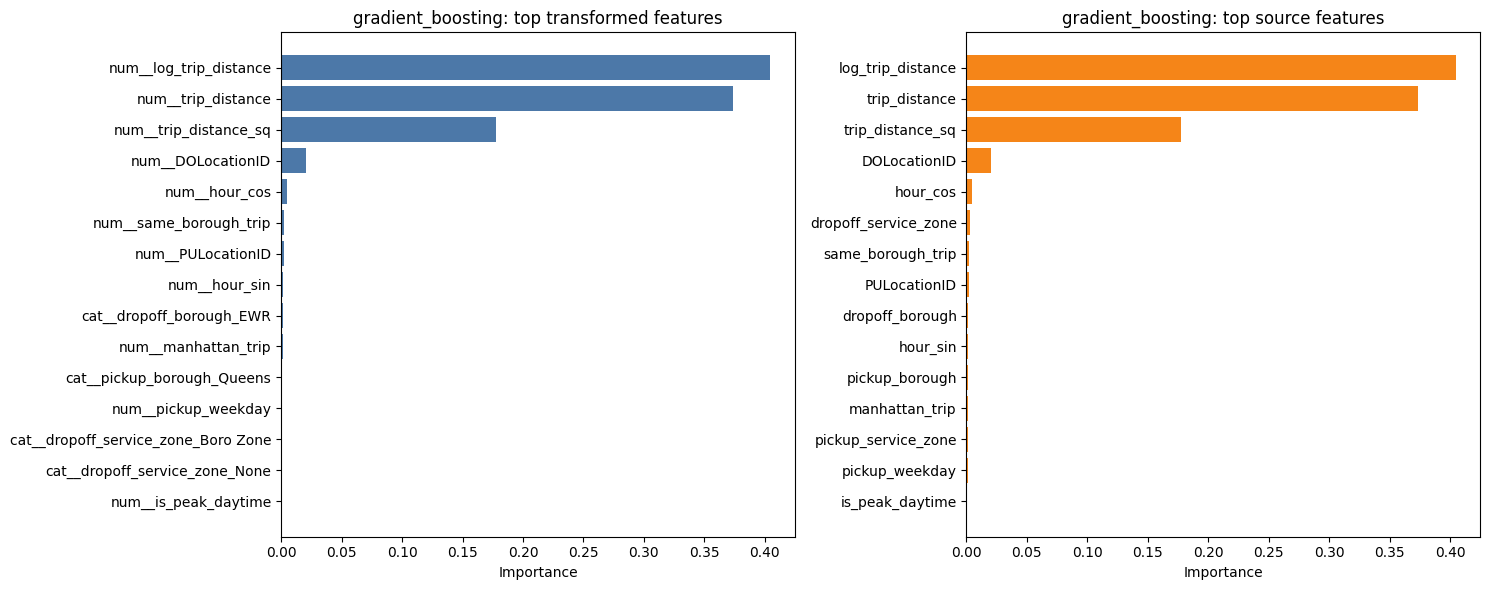

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

top_transformed = importances.head(15).sort_values("importance")
axes[0].barh(top_transformed["transformed_feature"], top_transformed["importance"], color="#4C78A8")
axes[0].set_title(f"{model_to_interpret}: top transformed features")
axes[0].set_xlabel("Importance")

top_grouped = grouped_importances.head(15).sort_values("importance")
axes[1].barh(top_grouped["source_feature"], top_grouped["importance"], color="#F58518")
axes[1].set_title(f"{model_to_interpret}: top source features")
axes[1].set_xlabel("Importance")

plt.tight_layout()
plt.show()


### Permutation importance on holdout data

Built-in feature importance is useful but model-specific. Permutation importance gives a second view by measuring how much holdout performance degrades when each feature is shuffled.


In [8]:
perm_sample_n = min(20_000, len(X_test))
perm_idx = X_test.sample(n=perm_sample_n, random_state=RANDOM_STATE).index
X_perm = X_test.loc[perm_idx]
y_perm = y_test.loc[perm_idx]

perm = permutation_importance(
    pipeline,
    X_perm,
    y_perm,
    scoring="neg_root_mean_squared_error",
    n_repeats=5,
    random_state=RANDOM_STATE,
    n_jobs=1,
)

perm_df = pd.DataFrame({
    "feature": X_perm.columns,
    "importance_mean": perm.importances_mean,
    "importance_std": perm.importances_std,
}).sort_values("importance_mean", ascending=False).reset_index(drop=True)

perm_df.head(15)


,feature,importance_mean,importance_std
0,log_trip_distance,3.573448,0.030944
1,trip_distance,2.782151,0.024942
2,trip_distance_sq,1.491058,0.013253
3,DOLocationID,0.441777,0.006083
4,pickup_borough,0.222981,0.006064
5,PULocationID,0.212228,0.003114
6,hour_cos,0.159832,0.016807
7,is_airport_dropoff,0.146390,0.004281
8,dropoff_service_zone,0.110413,0.008062
9,hour_sin,0.082674,0.014581


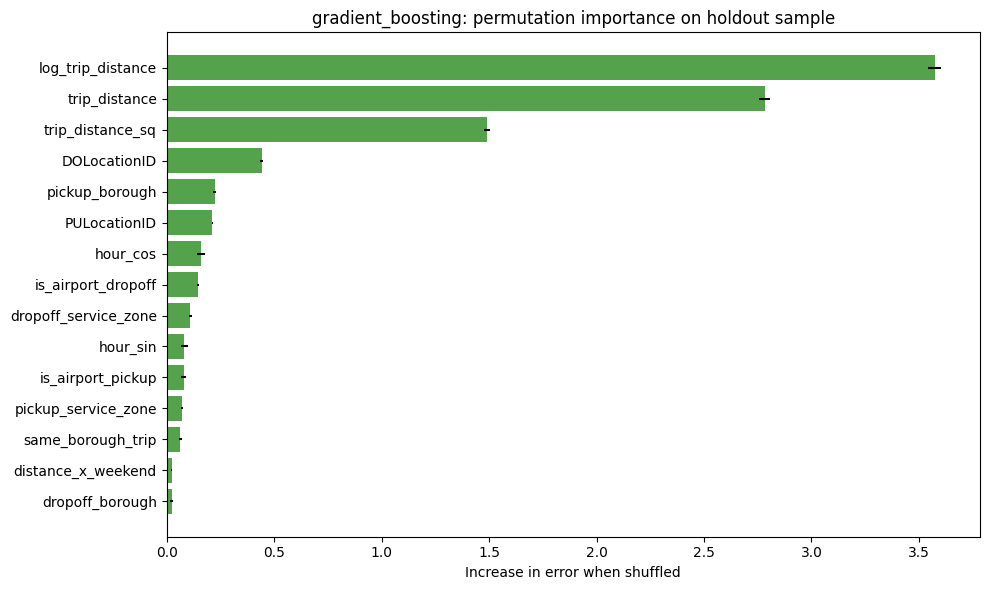

In [9]:
top_perm = perm_df.head(15).sort_values("importance_mean")

plt.figure(figsize=(10, 6))
plt.barh(top_perm["feature"], top_perm["importance_mean"], xerr=top_perm["importance_std"], color="#54A24B")
plt.title(f"{model_to_interpret}: permutation importance on holdout sample")
plt.xlabel("Increase in error when shuffled")
plt.tight_layout()
plt.show()


### Partial dependence for the strongest numeric drivers

Partial dependence plots provide a more intuitive view of how the model responds to the most important numeric variables.


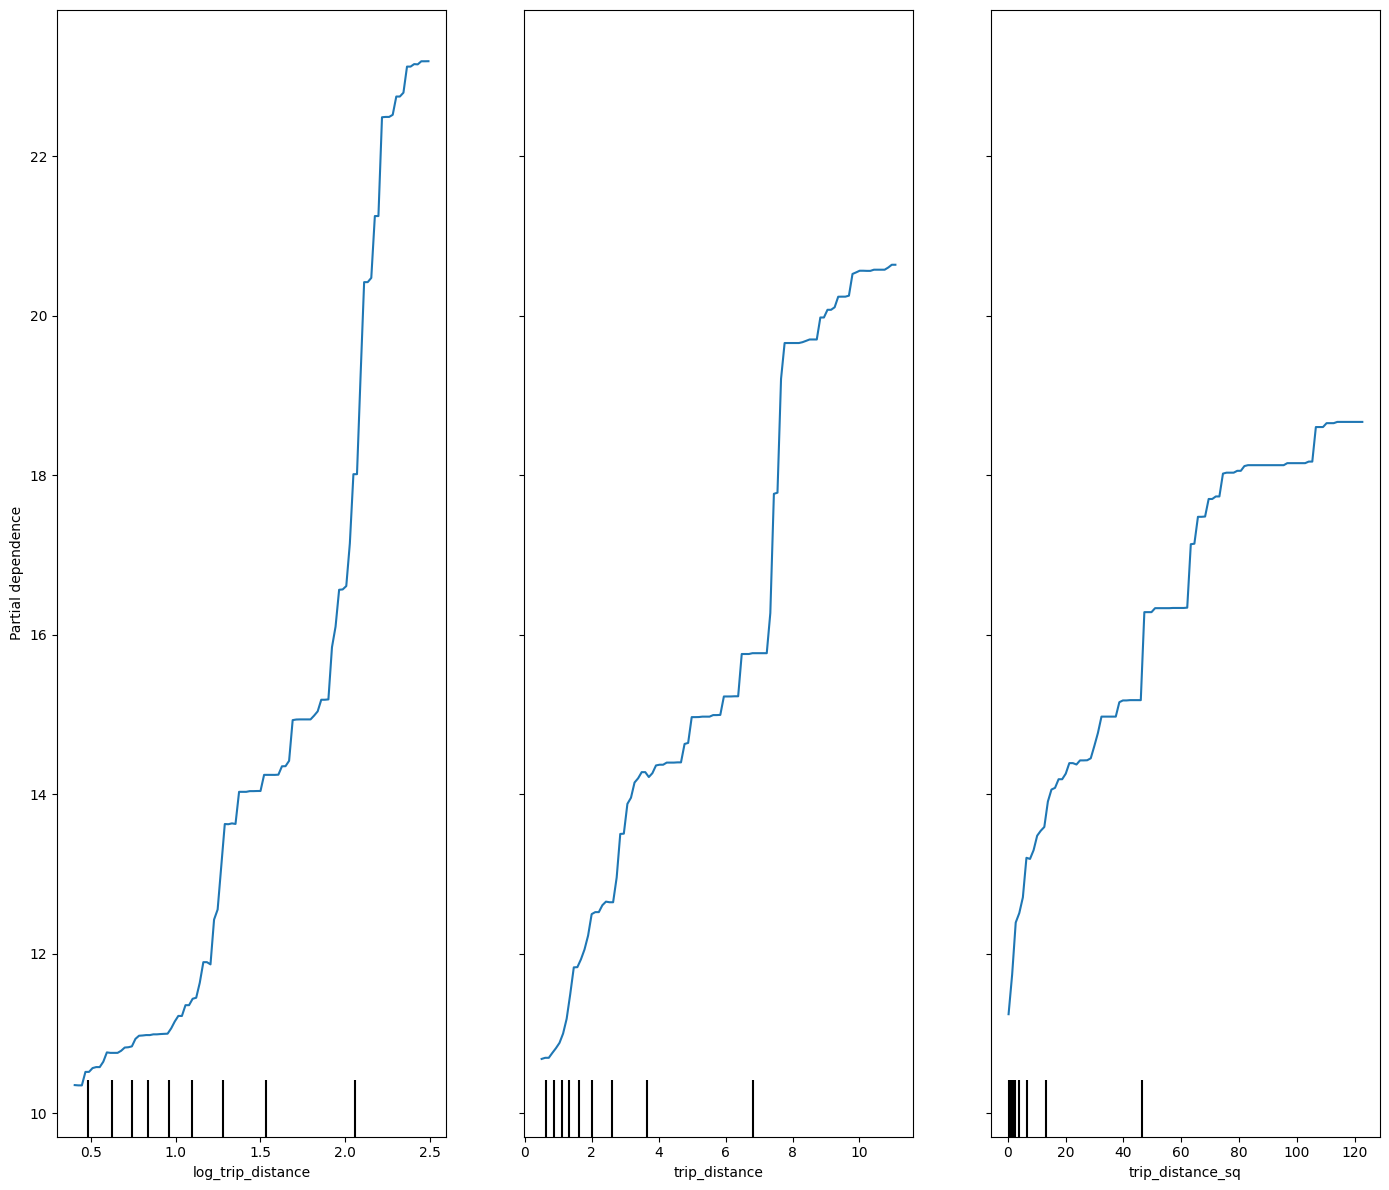

In [10]:
top_numeric_features = [f for f in grouped_importances["source_feature"] if f in numeric_cols][:3]

if top_numeric_features:
    pd_sample = X_test.sample(n=min(20_000, len(X_test)), random_state=RANDOM_STATE)
    fig, ax = plt.subplots(figsize=(14, 4 * len(top_numeric_features)))
    PartialDependenceDisplay.from_estimator(pipeline, pd_sample, features=top_numeric_features, ax=ax)
    plt.tight_layout()
    plt.show()
else:
    warnings.warn("No numeric features available for partial dependence.")


### Prediction and residual views

These charts help answer a practical question: where does the model still miss, and do those misses grow with fare level or trip distance?


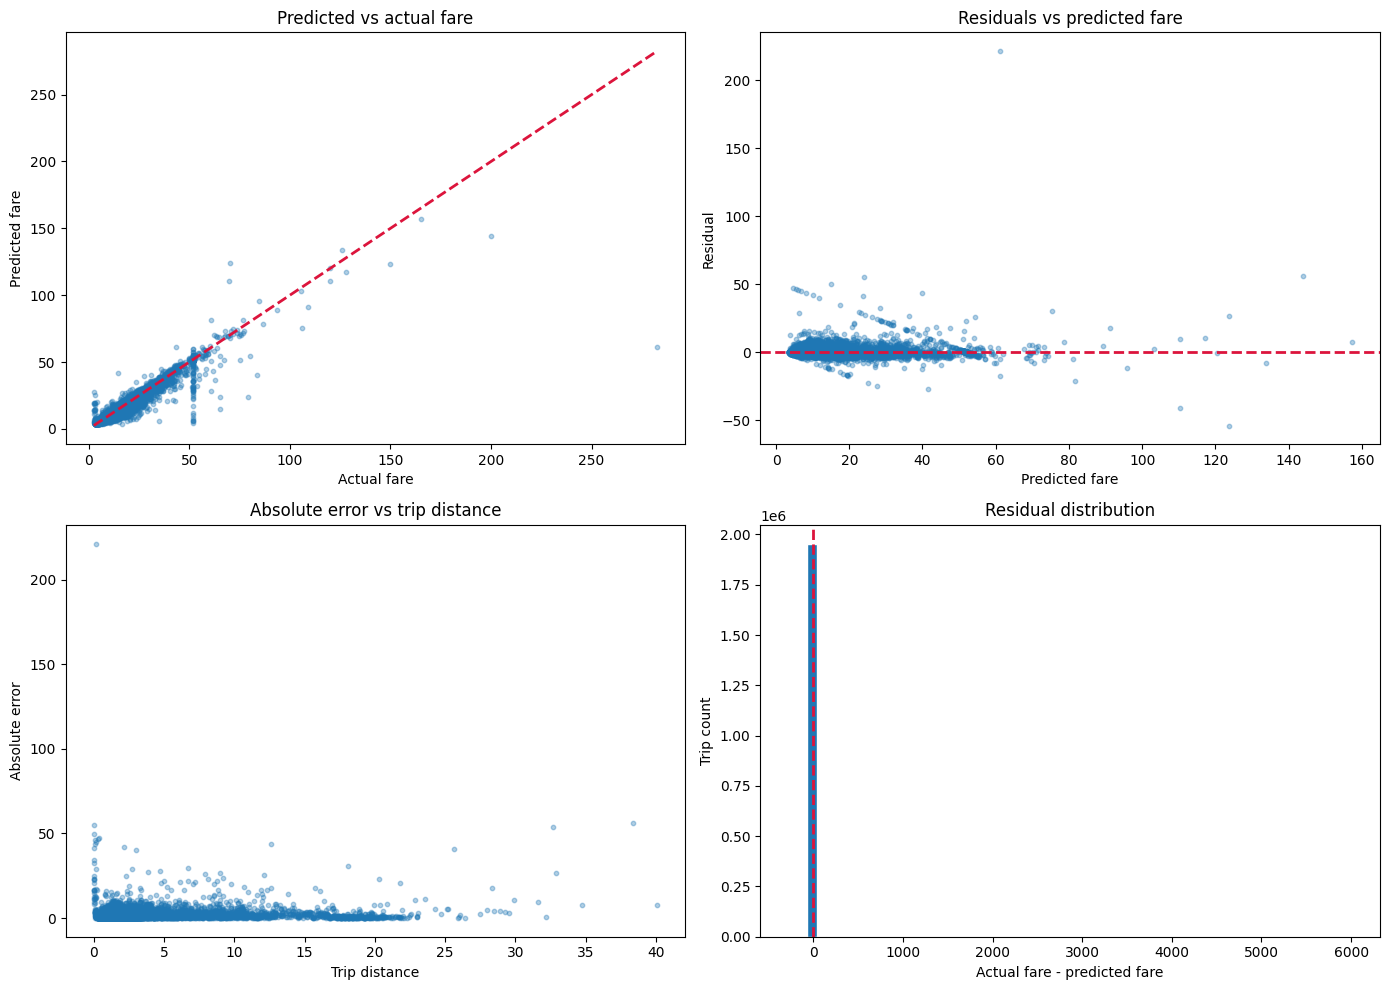

In [11]:
model_df = all_predictions_df.loc[all_predictions_df["model"] == model_to_interpret].copy()
plot_sample = model_df.sample(n=min(12_000, len(model_df)), random_state=RANDOM_STATE)
axis_min = float(min(plot_sample["actual_fare"].min(), plot_sample["predicted_fare"].min()))
axis_max = float(max(plot_sample["actual_fare"].max(), plot_sample["predicted_fare"].max()))

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

axes[0, 0].scatter(plot_sample["actual_fare"], plot_sample["predicted_fare"], s=10, alpha=0.35)
axes[0, 0].plot([axis_min, axis_max], [axis_min, axis_max], color="crimson", linestyle="--", linewidth=2)
axes[0, 0].set_title("Predicted vs actual fare")
axes[0, 0].set_xlabel("Actual fare")
axes[0, 0].set_ylabel("Predicted fare")

axes[0, 1].scatter(plot_sample["predicted_fare"], plot_sample["residual"], s=10, alpha=0.35)
axes[0, 1].axhline(0, color="crimson", linestyle="--", linewidth=2)
axes[0, 1].set_title("Residuals vs predicted fare")
axes[0, 1].set_xlabel("Predicted fare")
axes[0, 1].set_ylabel("Residual")

axes[1, 0].scatter(plot_sample["trip_distance"], plot_sample["abs_error"], s=10, alpha=0.35)
axes[1, 0].set_title("Absolute error vs trip distance")
axes[1, 0].set_xlabel("Trip distance")
axes[1, 0].set_ylabel("Absolute error")

axes[1, 1].hist(model_df["residual"], bins=60, edgecolor="white")
axes[1, 1].axvline(0, color="crimson", linestyle="--", linewidth=2)
axes[1, 1].set_title("Residual distribution")
axes[1, 1].set_xlabel("Actual fare - predicted fare")
axes[1, 1].set_ylabel("Trip count")

plt.tight_layout()
plt.show()


### Segment summaries that are easy to communicate

The tables below summarize where the chosen model performs well or poorly by borough and by fare band. These are the kinds of views that are often most useful in a presentation or short report.


In [12]:
borough_summary = (
    model_df.groupby("pickup_borough", observed=False)
    .agg(
        trips=("actual_fare", "size"),
        avg_actual_fare=("actual_fare", "mean"),
        mae=("abs_error", "mean"),
        rmse=("residual", lambda x: np.sqrt(np.mean(np.square(x)))),
    )
    .sort_values("mae", ascending=False)
    .round(3)
)

borough_summary


,trips,avg_actual_fare,mae,rmse
pickup_borough,,,,
EWR,48,89.892,20.805,29.107
Staten Island,61,48.298,8.405,14.581
Unknown,13511,15.174,3.210,10.359
Queens,125210,36.541,3.122,7.646
Bronx,1580,19.355,3.025,9.312
Brooklyn,17366,15.193,1.903,4.899
Manhattan,1795487,11.528,1.450,5.314


In [13]:
model_df = model_df.copy()
model_df["fare_band"] = pd.qcut(model_df["actual_fare"], q=10, duplicates="drop")

fare_band_summary = (
    model_df.groupby("fare_band", observed=False)
    .agg(
        trips=("actual_fare", "size"),
        avg_actual_fare=("actual_fare", "mean"),
        avg_predicted_fare=("predicted_fare", "mean"),
        mae=("abs_error", "mean"),
    )
    .round(3)
)

fare_band_summary


,trips,avg_actual_fare,avg_predicted_fare,mae
fare_band,,,,
"(0.009000000000000001, 5.0]",233079,4.406,5.215,0.934
"(5.0, 6.0]",186045,5.755,6.163,0.723
"(6.0, 7.0]",185578,6.748,7.073,0.812
"(7.0, 8.5]",251541,7.983,8.147,0.938
"(8.5, 9.5]",145323,9.241,9.220,1.111
"(9.5, 11.0]",180795,10.473,10.241,1.278
"(11.0, 13.5]",214837,12.412,11.851,1.600
"(13.5, 17.0]",180273,15.333,14.368,2.059
"(17.0, 25.0]",183155,20.544,19.200,2.542


### Reporting takeaway

A practical reading of this notebook is: identify the best loadable saved model, explain what drives its predictions, and show where it still makes the largest errors. That gives the project a more business-friendly ending than metrics alone.
